# 🔍 Feature Analysis
### Building a leakage-free, model-ready F1 dataset (2010–2024)

Inspects `data/processed/features.parquet` (built by `src.features.build_features`):
one row per driver per race, leakage-free by construction. This is the foundation
the race model (`03_model_results`) and qualifying model (`04_qualifying_model`)
are trained on.

---

### TL;DR

| | |
|---|---|
| 📦 **Dataset** | 6,432 driver-races · 305 races · 80 drivers · 23 constructors |
| 🎯 **Primary target** | `target_finish_position` (ordinal) + winner / podium / points |
| 📐 **Baseline to beat** | "finish = grid" ≈ **2.6 MAE** (2024) / ~3.1 all-years |
| 🔒 **Leakage** | max \|corr\| with finish sits **well under** the 0.95 flag |
| 🧠 **Dual-ELO** | validated: top ratings = the era's best, carried across teams |
| 🕳️ **Missingness** | every gap explained by design, flagged for the model |

> **This notebook, in order:** ① the dataset · ② what we predict · ③ the baseline ·
> ④ leakage audit · ⑤ rolling-feature hand check · ⑥ dual-ELO ratings ·
> ⑦ correlation structure · ⑧ missingness.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Resolve repo root no matter where the kernel started.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "features.parquet").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

features = pd.read_parquet(ROOT / "data" / "processed" / "features.parquet")

# --- one shared visual theme, applied to every chart below ---
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11, "axes.edgecolor": "#c8ccd0",
    "axes.grid": True, "grid.color": "#e9ebec", "grid.linewidth": 0.9,
    "axes.axisbelow": True, "legend.frameon": False,
    "xtick.color": "#4a4f55", "ytick.color": "#4a4f55", "axes.labelcolor": "#2b2f36",
})
C = {"baseline": "#9aa0a6", "rf": "#6b8fd4", "xgb": "#4c6ef5", "lgbm": "#12b886",
     "stack": "#e8590c", "good": "#2f9e44", "bad": "#e03131", "ink": "#2b2f36",
     "violet": "#7048e8"}

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

print("repo root:", ROOT)
print("features:", features.shape)
features.head(3)

repo root: D:\TUGAS\C Path\Portfolio\ML\f1-predictor
features: (7065, 58)


,season,round,driver_id,driver_code,constructor_id,grid,finish_position,points,status,race_date,...,humidity_avg,wind_speed_avg,rain_flag,weather_source,weather_missing,target_finish_position,target_is_dnf,target_is_winner,target_is_podium,target_is_points
0,2010,1,vettel,VET,red_bull,1,4.0,12.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,4.0,0,0,0,1
1,2010,1,massa,MAS,ferrari,2,2.0,18.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,2.0,0,0,1,1
2,2010,1,alonso,ALO,ferrari,3,1.0,25.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,1.0,0,1,1,1


## 1 · The dataset at a glance

In [2]:
print("Seasons   :", int(features['season'].min()), "->", int(features['season'].max()))
print("Races     :", features[['season','round']].drop_duplicates().shape[0])
print("Drivers   :", features['driver_id'].nunique(),
      "| Constructors:", features['constructor_id'].nunique())
print("Rows      :", len(features))
dupes = features.duplicated(['season','round','driver_id']).sum()
print("Grain     : duplicate (season,round,driver) rows =", dupes, "(expect 0)")
n_tgt = len([c for c in features.columns if c.startswith('target_')])
print("Columns   :", features.shape[1], f"({features.shape[1]-n_tgt} feature/meta + {n_tgt} targets)")

Seasons   : 2010 -> 2026
Races     : 336
Drivers   : 84 | Constructors: 25
Rows      : 7065
Grain     : duplicate (season,round,driver) rows = 0 (expect 0)
Columns   : 58 (53 feature/meta + 5 targets)


## 2 · What are we predicting?

The primary target is `target_finish_position` (ordinal regression); the binary
targets (winner / podium / points) are derived by ranking within each race.

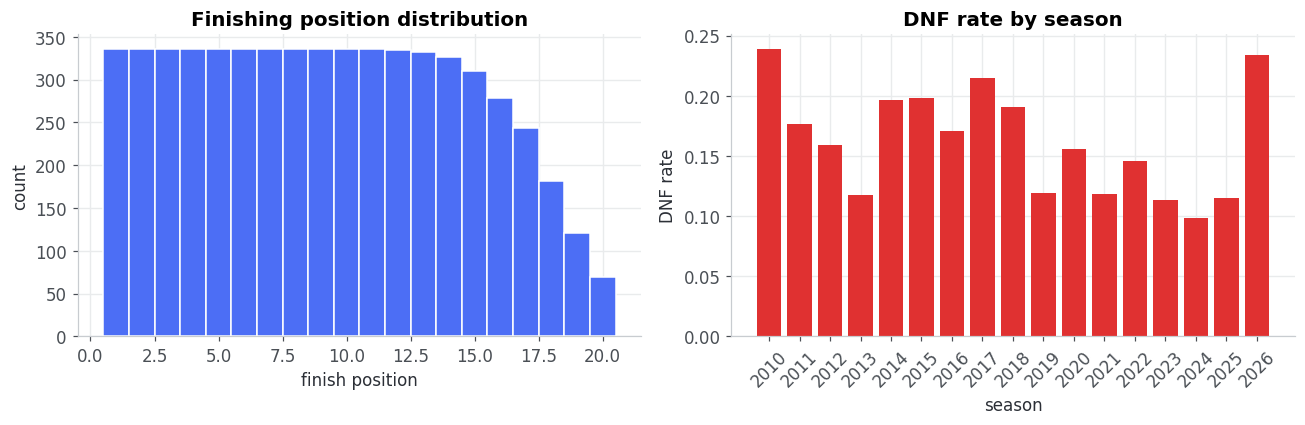

Target base rates:
  target_is_winner     0.048
  target_is_podium     0.143
  target_is_points     0.476
  target_is_dnf        0.159


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fin = features['target_finish_position'].dropna()
axes[0].hist(fin, bins=np.arange(0.5, 21.5, 1), color=C["xgb"], edgecolor='white')
axes[0].set(title='Finishing position distribution', xlabel='finish position', ylabel='count')
despine(axes[0])

dnf_by_season = features.groupby('season')['target_is_dnf'].mean()
axes[1].bar(dnf_by_season.index.astype(str), dnf_by_season.values, color=C["bad"])
axes[1].set(title='DNF rate by season', xlabel='season', ylabel='DNF rate')
axes[1].tick_params(axis='x', rotation=45); despine(axes[1])
plt.tight_layout(); plt.show()

print("Target base rates:")
for t in ['target_is_winner','target_is_podium','target_is_points','target_is_dnf']:
    print(f"  {t:20s} {features[t].mean():.3f}")

## 3 · The baseline to beat — "finish = grid"

"Predict finish = grid" is the floor every model must clear, measured on the
actual modelling splits below.

**Measured vs. planned:** the real grid baseline is ~2.6 MAE on the 2024 test
season and ~3.1 across all years — *higher* than the PRD's ~2.1 estimate, which
under-counted the heavy attrition of the early-2010s. Phase 3 benchmarks against
these measured numbers; the PRD's absolute ≤1.5 goal remains a stretch target.

split,MAE,Spearman,n
all 2010-2024,3.10,0.761,5944
val 2023,3.30,0.680,390
test 2024,2.61,0.785,432


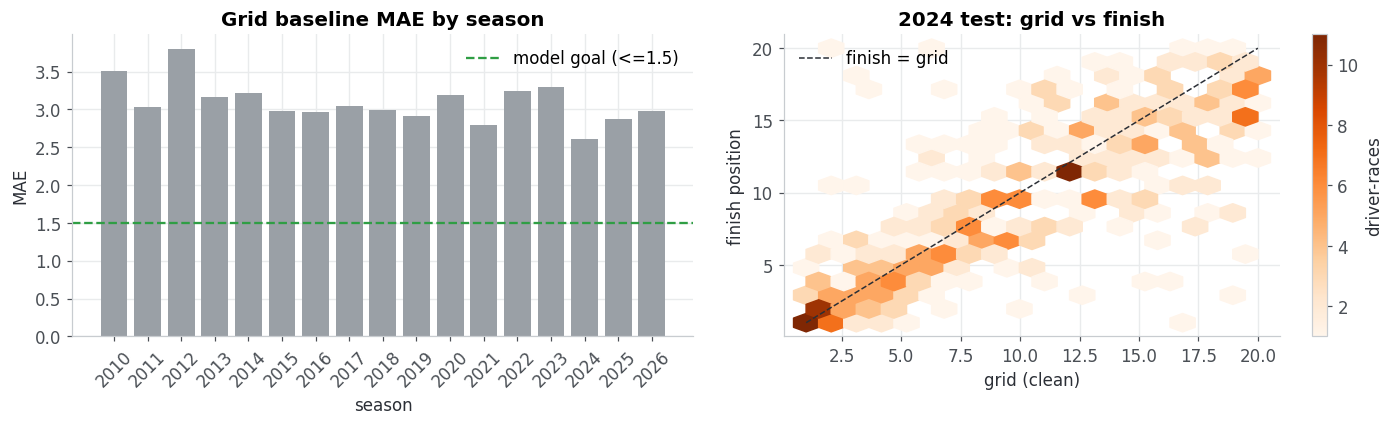

In [4]:
def grid_baseline(frame):
    f = frame[frame['target_finish_position'].notna()]
    mae = (f['grid_clean'] - f['target_finish_position']).abs().mean()
    rho = f['grid_clean'].corr(f['target_finish_position'], method='spearman')
    return mae, rho, len(f)

splits = {'all 2010-2024': features,
          'val 2023': features[features.season == 2023],
          'test 2024': features[features.season == 2024]}
base_tbl = pd.DataFrame(
    [{'split': name, 'MAE': (m := grid_baseline(fr))[0], 'Spearman': m[1], 'n': m[2]}
     for name, fr in splits.items()])
display(base_tbl.style
        .format({'MAE': '{:.2f}', 'Spearman': '{:.3f}', 'n': '{:d}'})
        .background_gradient(subset=['MAE'], cmap='RdYlGn_r')
        .set_caption('Grid baseline — "finish = grid"')
        .hide(axis='index'))

c = features[features['target_finish_position'].notna()].copy()
c['ae'] = (c['grid_clean'] - c['target_finish_position']).abs()
by_season = c.groupby('season')['ae'].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(by_season.index.astype(str), by_season.values, color=C["baseline"])
ax[0].axhline(1.5, color=C["good"], ls='--', label='model goal (<=1.5)')
ax[0].set(title='Grid baseline MAE by season', xlabel='season', ylabel='MAE')
ax[0].tick_params(axis='x', rotation=45); ax[0].legend(); despine(ax[0])

test = features[(features.season == 2024) & features['target_finish_position'].notna()]
hb = ax[1].hexbin(test['grid_clean'], test['target_finish_position'],
                  gridsize=18, cmap='Oranges', mincnt=1)
ax[1].plot([1, 20], [1, 20], '--', color=C["ink"], lw=1, label='finish = grid')
ax[1].set(title='2024 test: grid vs finish', xlabel='grid (clean)', ylabel='finish position')
ax[1].legend(); despine(ax[1]); fig.colorbar(hb, ax=ax[1], label='driver-races')
plt.tight_layout(); plt.show()

## 4 · Leakage audit — is any feature cheating?

Re-runs the same `leakage_audit` that fires on every build. Grid and qualifying
features are *expected* to correlate strongly — that is signal, not leakage. The
red line at 0.95 is the flag threshold: any feature past it would be silently
carrying the post-race result.

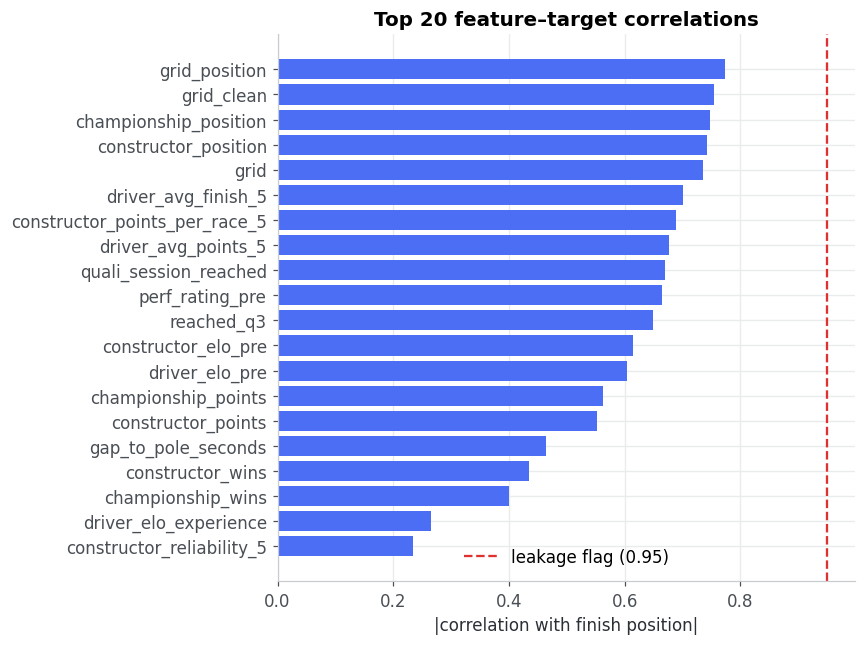

✅ Max |corr| with finish = 0.773  <  0.95  ->  audit CLEAN


In [5]:
from src.features.build_features import leakage_audit

audit = leakage_audit(features, threshold=0.95)
top = audit.head(20)
colors = [C["bad"] if a >= 0.95 else C["xgb"] for a in top['abs_corr']]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top['feature'][::-1], top['abs_corr'][::-1], color=colors[::-1])
ax.axvline(0.95, color=C["bad"], ls='--', label='leakage flag (0.95)')
ax.set_xlabel('|correlation with finish position|')
ax.set_title('Top 20 feature–target correlations'); ax.legend(); despine(ax)
plt.tight_layout(); plt.show()

assert audit['abs_corr'].max() < 0.95, "Potential leakage — investigate!"
print(f"✅ Max |corr| with finish = {audit['abs_corr'].max():.3f}  <  0.95  ->  audit CLEAN")

## 5 · Are the rolling features leakage-free? (hand check)

`driver_avg_finish_5` must equal the mean of a driver's *previous* up-to-5
finishes (DNF imputed to 20), never including the current race. We recompute it
by hand for one driver and assert equality.

In [6]:
ver = features[features.driver_id == 'max_verstappen'].sort_values('race_order')
finishes = ver['target_finish_position'].fillna(20).to_numpy()
manual = np.array([np.nan] + [finishes[max(0, i-5):i].mean() for i in range(1, len(finishes))])

chk = ver[['season', 'round', 'target_finish_position', 'driver_avg_finish_5']].copy()
chk['hand_recomputed'] = manual
ok = np.allclose(chk['driver_avg_finish_5'].to_numpy()[1:], manual[1:], equal_nan=True)
print("✅ driver_avg_finish_5 == hand-recomputed trailing mean (current race excluded):", ok)
display(chk.head(8).style
        .format({'target_finish_position': '{:.0f}', 'driver_avg_finish_5': '{:.2f}',
                 'hand_recomputed': '{:.2f}'}, na_rep='—')
        .set_caption('driver_avg_finish_5 vs hand recomputation (first 8 races)')
        .hide(axis='index'))

✅ driver_avg_finish_5 == hand-recomputed trailing mean (current race excluded): True


season,round,target_finish_position,driver_avg_finish_5,hand_recomputed
2015,1,—,—,—
2015,2,7,20.00,20.00
2015,3,17,13.50,13.50
2015,4,—,14.67,14.67
2015,5,11,16.00,16.00
2015,6,—,15.00,15.00
2015,7,15,15.00,15.00
2015,8,8,16.60,16.60


## 6 · Driver & constructor skill — the dual-ELO

A plain ELO conflates driver skill with car performance. The dual-ELO routes most
of each result's surprise to the *constructor* rating, so the *driver* rating
moves only when a driver beats what the car alone predicts. Ratings carry forward
across seasons and team changes.

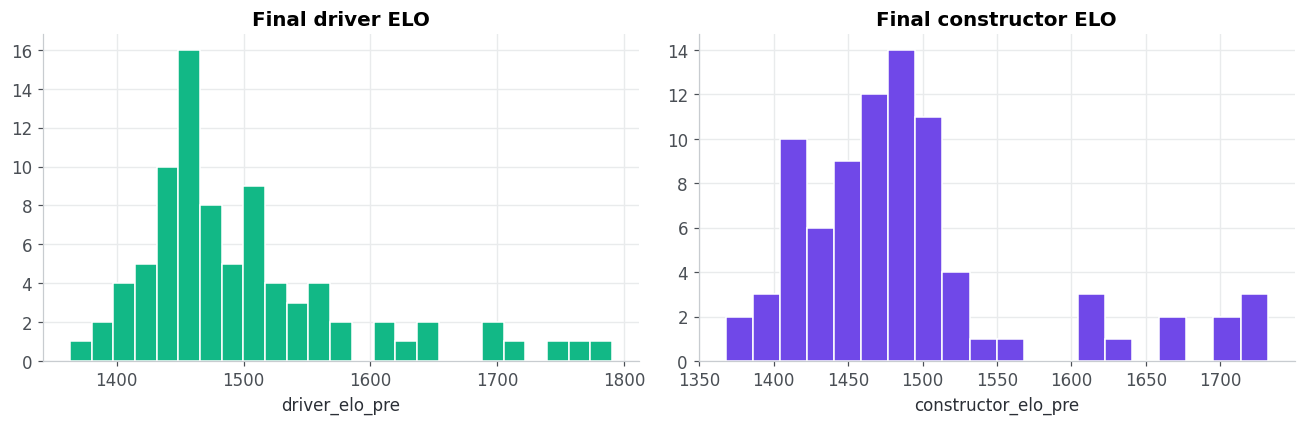

driver_code,driver_elo_pre
VER,1791
NOR,1763
ROS,1751
LEC,1705
HAM,1705
PIA,1705
WEB,1652
SAI,1647
RUS,1633
VET,1615


driver_code,driver_elo_pre
GLO,1363
KOV,1384
CHI,1390
TRU,1407
PIC,1408
LAT,1413
TSU,1414
ERI,1418
KAR,1420
WEH,1425


In [7]:
final = features.sort_values('race_order').groupby('driver_id').tail(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(final['driver_elo_pre'], bins=25, color=C["lgbm"], edgecolor='white')
axes[0].set(title='Final driver ELO', xlabel='driver_elo_pre'); despine(axes[0])
axes[1].hist(final['constructor_elo_pre'], bins=20, color=C["violet"], edgecolor='white')
axes[1].set(title='Final constructor ELO', xlabel='constructor_elo_pre'); despine(axes[1])
plt.tight_layout(); plt.show()

top10 = final.nlargest(10, 'driver_elo_pre')[['driver_code', 'driver_elo_pre']].reset_index(drop=True)
bot10 = final.nsmallest(10, 'driver_elo_pre')[['driver_code', 'driver_elo_pre']].reset_index(drop=True)
sty = lambda d, cap, cmap: (d.style.format({'driver_elo_pre': '{:.0f}'})
                            .background_gradient(subset=['driver_elo_pre'], cmap=cmap)
                            .set_caption(cap).hide(axis='index'))
display(sty(top10, 'TOP 10 drivers by ELO (face validity)', 'Greens'))
display(sty(bot10, 'BOTTOM 10 drivers by ELO', 'Reds_r'))

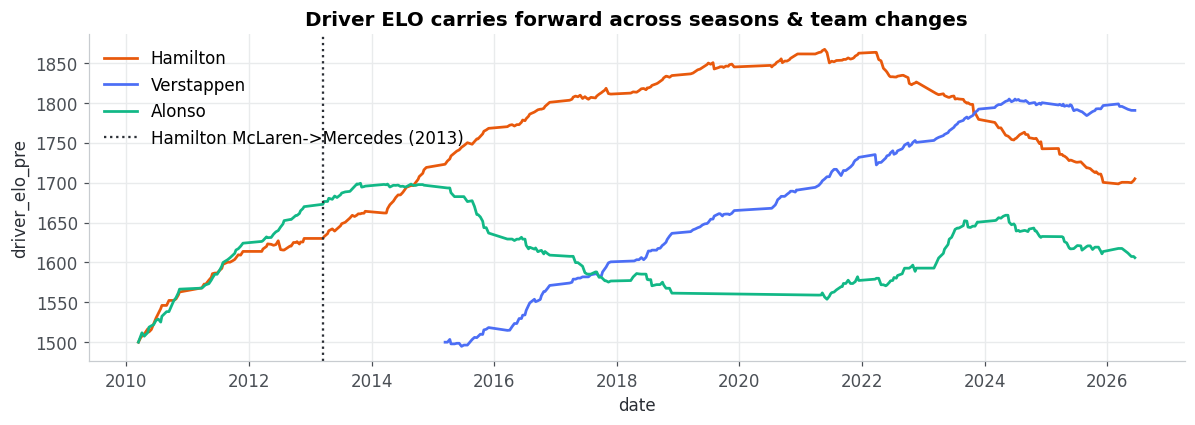

In [8]:
# Carry-forward across seasons & team changes: ratings never reset.
fig, ax = plt.subplots(figsize=(11, 4))
line_colors = [C["stack"], C["xgb"], C["lgbm"]]
for (did, name), col in zip(
        [('hamilton', 'Hamilton'), ('max_verstappen', 'Verstappen'), ('alonso', 'Alonso')], line_colors):
    d = features[features.driver_id == did].sort_values('race_order')
    ax.plot(pd.to_datetime(d['race_date']), d['driver_elo_pre'], label=name, lw=1.8, color=col)

ham13 = features[(features.driver_id == 'hamilton') & (features.season == 2013)] \
    .sort_values('race_order').head(1)
if len(ham13):
    ax.axvline(pd.to_datetime(ham13['race_date'].iloc[0]), color=C["ink"], ls=':',
               label='Hamilton McLaren->Mercedes (2013)')
ax.set(title='Driver ELO carries forward across seasons & team changes',
       xlabel='date', ylabel='driver_elo_pre')
ax.legend(); despine(ax); plt.tight_layout(); plt.show()

## 7 · Correlation structure — any redundancy?

Among the strongest features, looking for multicollinearity (e.g. ELO vs.
championship position vs. rolling finish all encode "current strength").

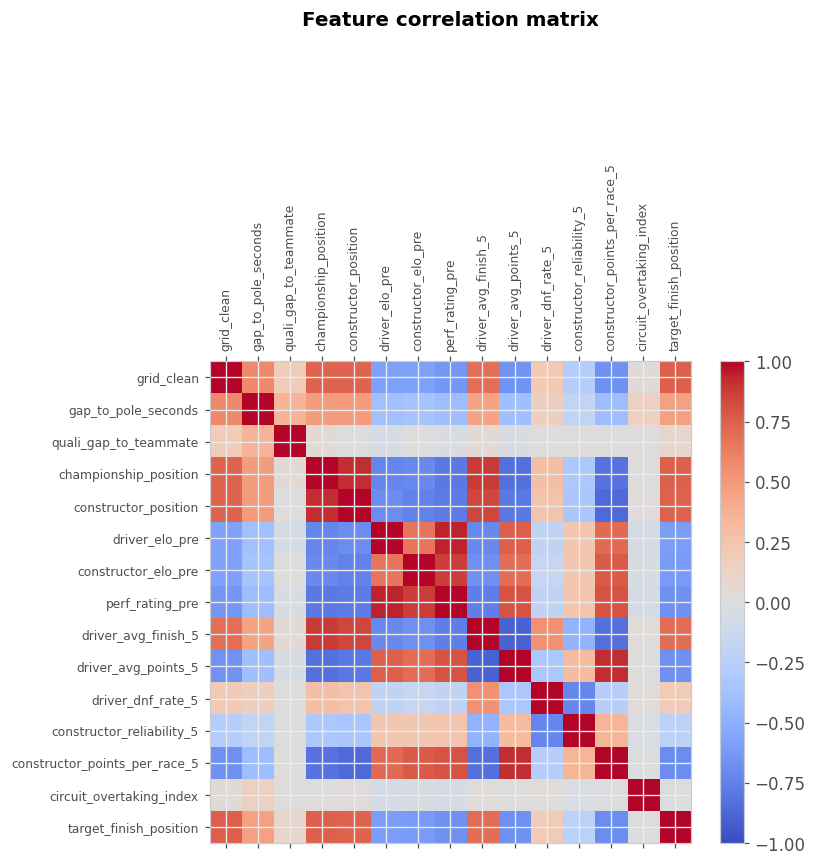

In [9]:
key = ['grid_clean', 'gap_to_pole_seconds', 'quali_gap_to_teammate',
       'championship_position', 'constructor_position', 'driver_elo_pre',
       'constructor_elo_pre', 'perf_rating_pre', 'driver_avg_finish_5',
       'driver_avg_points_5', 'driver_dnf_rate_5', 'constructor_reliability_5',
       'constructor_points_per_race_5', 'circuit_overtaking_index',
       'target_finish_position']
corr = features[key].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(key))); ax.set_xticklabels(key, rotation=90, fontsize=8)
ax.set_yticks(range(len(key))); ax.set_yticklabels(key, fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Feature correlation matrix', pad=90)
plt.tight_layout(); plt.show()

## 8 · Missingness — is every gap explained?

Every missing value is intentional. The flags (`weather_missing`,
`driver_form_races`, `circuit_history_races`) let the model treat them explicitly
rather than silently imputing.

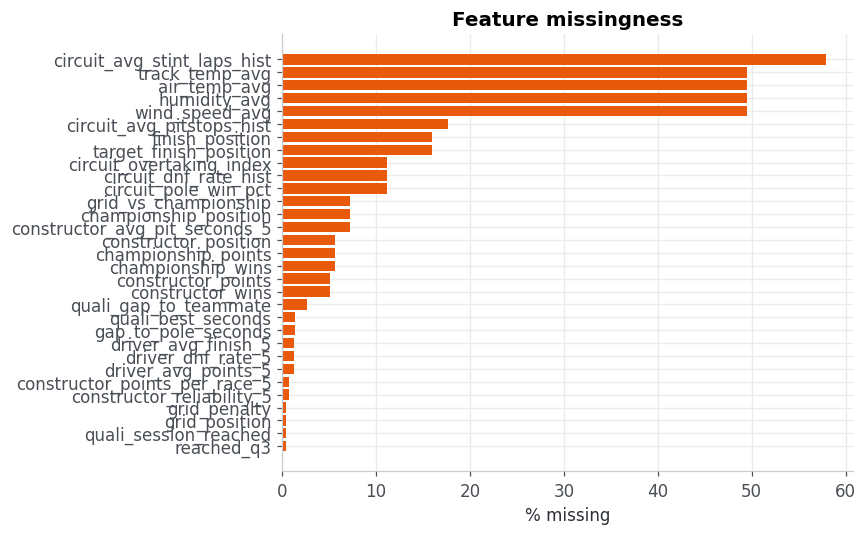

Weather source coverage (per race):
weather_source
fastf1    178
none      158
Name: count, dtype: int64

Why values are missing (by design, not error):
  - weather_* pre-2018 : FastF1 is 2018+; OWM fallback inert without API key
  - championship_* at round 1 : no within-season prior round
  - circuit_*_hist on first visit : no prior race at that circuit
  - circuit_avg_stint_laps_hist : tyre-stint data is 2018+ only


In [10]:
null_share = features.isna().mean()
ns = (null_share[null_share > 0].sort_values(ascending=False) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ns.index[::-1], ns.values[::-1], color=C["stack"])
ax.set_xlabel('% missing'); ax.set_title('Feature missingness'); despine(ax)
plt.tight_layout(); plt.show()

print("Weather source coverage (per race):")
print(features.drop_duplicates(['season', 'round'])['weather_source'].value_counts())
print("\nWhy values are missing (by design, not error):")
print("  - weather_* pre-2018 : FastF1 is 2018+; OWM fallback inert without API key")
print("  - championship_* at round 1 : no within-season prior round")
print("  - circuit_*_hist on first visit : no prior race at that circuit")
print("  - circuit_avg_stint_laps_hist : tyre-stint data is 2018+ only")

## 9 · Takeaways

- **Baseline is strong but beatable** — the *measured* grid baseline is ~2.6 MAE /
  0.79 Spearman on the 2024 test season (~3.1 across all years), above the PRD's
  ~2.1 estimate; the ≤1.5 MAE goal is a stretch.
- **No leakage** — the strongest legitimate signal (grid) tops out well under the
  0.95 flag; rolling features verified to exclude the current race.
- **Dual-ELO has face validity** — top ratings are the era's strongest drivers,
  and ratings carry across team changes without reset.
- **Missingness is fully explained** by design and flagged for the model.

Ready for **Phase 3 — modeling** (`03_model_results`), on the strict temporal
split: train 2010–2022, validate 2023, test 2024.

## 10 · Related — predicting the grid itself

This notebook treats the starting grid as a strong *given* input to the race
model. But before qualifying happens there is no grid to feed it, so a **second
model predicts `grid_clean` itself** — from a strictly quali-safe subset of these
same features (every grid/qualifying-derived column removed) plus new
rolling-grid history features. Its end-to-end feature analysis, training, and
evaluation live in **`04_qualifying_model.ipynb`**, forming stage 1 of the
two-stage, pre-qualifying pipeline.